# Functions

Learning Goals:

1. function basics
2. functions as objects
3. variable scopes
4. `lambda` functions

## Function basics

In [1]:
def boldly_print(k):  # colon ends declaration and begins definition
    for o in range(k):
        print('To boldly go')
    
boldly_print(2)

To boldly go
To boldly go


Unlike in C++:
- we do not specify a type for the parameters;
- we do not specify a `return` type; by default, `None` will be automatically returned.
  
The `None` keyword is used to define a null value, or no value at all.

In [2]:
print(boldly_print(2))

To boldly go
To boldly go
None


In [3]:
def boldly_print(k):
    for i in range(k):
        print('to boldly go')
    return

print(boldly_print(2))

to boldly go
to boldly go
None


**default arguments**

In [4]:
# you can have default arguments
def boldly_print(k, verb = 'go'):
    for i in range(k):
        print('to boldly ' + verb)

boldly_print(2)
boldly_print(2, 'sing')

to boldly go
to boldly go
to boldly sing
to boldly sing


In [5]:
# but non-default args need to come first


# doing like (verb = 'go',k)     is an error

**positional arguments** - Python knows what's k and what's verb based on the positions (orb order) they're given

**keyword arguments** - Python knows what's k and what's verb based on the keywords

In [6]:
def boldly_print(k, verb = 'go'):
    for i in range(k):
        print('to boldly ' + verb)

boldly_print(2, 'sing')
boldly_print(k=2, verb = 'sing')

to boldly sing
to boldly sing
to boldly sing
to boldly sing


In [7]:
# order is not important because we have keywords
boldly_print(verb = 'sing', k =2)

to boldly sing
to boldly sing


In [8]:
# but the keywords need to match the name of args.


In [9]:
# you can use both pos. args and keyword args, but pos. args need to come before keyword args.
boldly_print(2, verb='go')

to boldly go
to boldly go


## Function objects

In Python, defining a function creates a function object.

In [10]:
def f():
    pass

`f` behaves like a variable.

In particular, `f` labels a box containing a `type` and an `object` reference.

The type is `function`.

It references a `function object`.

In [11]:
print(type(f), id(f))

<class 'function'> 4408481344


In [12]:
# compute the absolute value
def abs_val(n):
    if n > 0:
        return n
    return -n

print(type(abs_val), id(abs_val))


<class 'function'> 4408636368


In [13]:
# A function object can be re-assigned
f = abs_val
print(type(f), id(f))

<class 'function'> 4408636368


Thus, it is extremely easy (when one compares with C++) to pass a function to another function in Python.

In [14]:
def printSum(L):
    res = 0
    for e in L:
        res += e 
    print(res)

In [15]:
def g(func):
    func([1,2,3])
    func([4,5,6,7])

In [16]:
g(printSum)

6
22


## Function scope

Global and local scope of variables

Variables in the global scope are available within the function.
Variables created within the function are not available within the global scope.

In [17]:
# available in global scope
x= 2

In [18]:
# variables within the global scope are available within the function
def print_x():
    print(x)

print_x()

2


In [20]:
def print_y():
    y = 4 
    print(y)

print_y()

4


When a function is called and there's a reference to a name:

First look for it in the local scope, i.e. variables declared/assigned inside the function definition.
If you don't see it, then look for variables in the global scope.

In [21]:
x = 2 
def new_x():
    print(x)

x = 8 

new_x()

8


**The default values are stored in the function object at the time the function is defined.**

In [22]:
i = 5 
def f(arg=i):
    print(arg)

i = 7 
f()

5


In [24]:
def f(a, L = []):
    L.append(a)
    return L


print(f(1))
print(f(2))
print(f(3))

[1]
[1, 2]
[1, 2, 3]


In [25]:
x = [] 
def f (a, L =x):
    L.append(a)
    return L

print(f(1))
x.append(4)
print(f(2))

[1]
[1, 4, 2]


In [26]:
def f(a, L = None):
    if L is None:
        L = []
    L.append(a)
    return L

print(f(1))
print(f(2))
print(f(3))

[1]
[2]
[3]


## `lambda` functions

Another way to write function: using the `lambda` keyword

In [27]:
# "double is the function that takes x and multiplies it by 2"
double = lambda x: 2 *x

print(type(double))

<class 'function'>


The syntax: function_name, assignment, lambda keyword, parameters, colon, what you want to return.

In [28]:
# "second_char is the function that returns the second character of a string s"
second_char = lambda s: s[1]
second_char('hello')

'e'

In [29]:
# "multiply returns the product of x and y"
multiply = lambda x,y: x*y
multiply(3,4)

12

Using a lambda function with the sort function is a common usage.

In [30]:
# Example 1:
M = [16,7,8,4,5]
M.sort()
print(M)

[4, 5, 7, 8, 16]


In [31]:
# sort elements in decreasing order
M = [16,7,8,9]
M.sort(reverse = True)
print(M)

[16, 9, 8, 7]


In [33]:
M = [16,7,2,3,9]
M.sort(key = lambda x: -x)
print(M)

[16, 9, 7, 3, 2]


In [34]:
# Example 2
names = ['Adams', 'Mary', 'derek', 'James']
names.sort()
print(names)

['Adams', 'James', 'Mary', 'derek']


In [35]:
names = ['Adams', 'Mary', 'derek', 'James']
names.sort(key = lambda s: s.lower())
print(names)

['Adams', 'derek', 'James', 'Mary']


In [37]:
# Example 3
M = [[2,2], [1,3], [3,1], [2,3]]
M.sort()
print(M)

[[1, 3], [2, 2], [2, 3], [3, 1]]


In [38]:
M = [[2,2], [1,3], [3,1],[2,3]]
M.sort(reverse = True)
print(M)

[[3, 1], [2, 3], [2, 2], [1, 3]]


In [39]:
M = [[2,2], [1,3], [3,1],[2,3]]
M.sort(key = lambda L: L[1])
print(M)

[[3, 1], [2, 2], [1, 3], [2, 3]]


Python documentation for sort function: https://docs.python.org/3/howto/sorting.html

## Exercise: simulate a random walk

Random walks are commonly used to model phenomena in physics,  chemistry, biology, and finance. In a simple random walk, at each timestep we flip a fair coin. If heads, we move foward one step; if tails, we move backwards. Let "forwards" be represented by positive integers, and "backwards" be represented by negative integers. For example, if we are currently three steps backwards from the starting point 0, our position is `-3`. 

Write a `random_walk` function to simulate a random walk. Your function should: 

- Take an upper and lower bound as inputs.
- Return three variables `pos`, `positions`, `steps`, in that order.
- `pos` is an integer, and indicates the walk's final position at termination.
- `positions` is a list of integers, and it is a log of the position of the walk at each time step.
- `steps` is a list of integers, and it is a log of the results of the coin flips. 

When the walk reaches the upper or lower bound, print a message such as `Upper bound at 3 reached` and terminate the walk. 

In [40]:
# simulating a coin flip
import random 
for i in range(5):
    x = random.choice(['heads','tailts'])
    print(x)

heads
tailts
heads
tailts
heads


In [41]:
#You don't have to use "heads" and "tails" when using this function 
for i in range(5):
    x = random.choice([1,-1])
    print(x)

1
-1
1
1
1


- **Python Docstrings**: Functions (and, later, classes) should be accompanied by a *docstring*. Briefly, the docstring should provide enough information that a user could correctly use your function ***without seeing the code.*** In somewhat more detail, the docstring should include the following information: 
    - One or more sentences describing the overall purpose of the function. 
    - An explanation of each of the inputs, including what they mean, their required data types, and any additional assumptions made about them.
    - An explanation of the outputs. 

In [47]:
# solution
def random_walk(upper_bound, lower_bound):
    """  
    Simulate a simple  unbiased random walk. 
    Terminiate when walk reaches upper or lower bound. initial pos is 0 

    Args:  
        upper_bound is an int, upper bound of walk
        lower_bound is an int, lower bound of walk

    Returns:
        pos: an int, walk final pos
        positions: list of ints, log of walks pos
        steps: a listo f ints, a log of the coin flips
    """

    pos = 0
    positions = [0]
    steps = []

    while True:
        x = random.choice([1,-1])
        pos += x 
        steps.append(x)


        if pos >= upper_bound:
            print('Upper bound reached')
            break
        elif pos <= lower_bound:
            print('Lower bound reached')
            break

        positions.append(pos)

    return pos, positions, steps

In [49]:
pos, positions, steps = random_walk(100,-100)

Upper bound reached


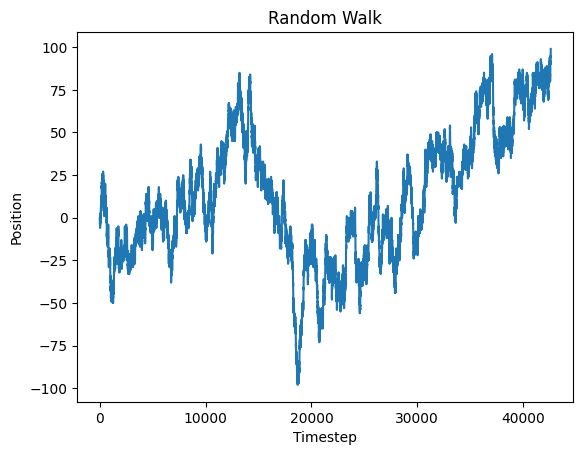

In [50]:
# visulize the random walk (will be covered in future lectures)
from matplotlib import pyplot as plt
plt.plot(positions)
plt.xlabel('Timestep')
plt.ylabel('Position')
plt.title('Random Walk')
plt.show()

### 